### Install libraries

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn flask xgboost

### Epic 1 : Data Collection

#### Download the Dataset

### Epic 2: Visualising and Analysing the Data

#### import the libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

#### Read the Dataset

In [3]:
app = pd.read_csv(r'application_record[1].csv')
credit = pd.read_csv(r'credit_record[1].csv')
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
# Check the shape of both datasets (rows, columns)
print("Application dataset shape:", app.shape)
print("Credit dataset shape:", credit.shape)

Application dataset shape: (438557, 18)
Credit dataset shape: (1048575, 3)


In [5]:
# Display dataset information - column names, data types, and missing values
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

#### Univariate Analysis

Number of people in each occupation type:
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


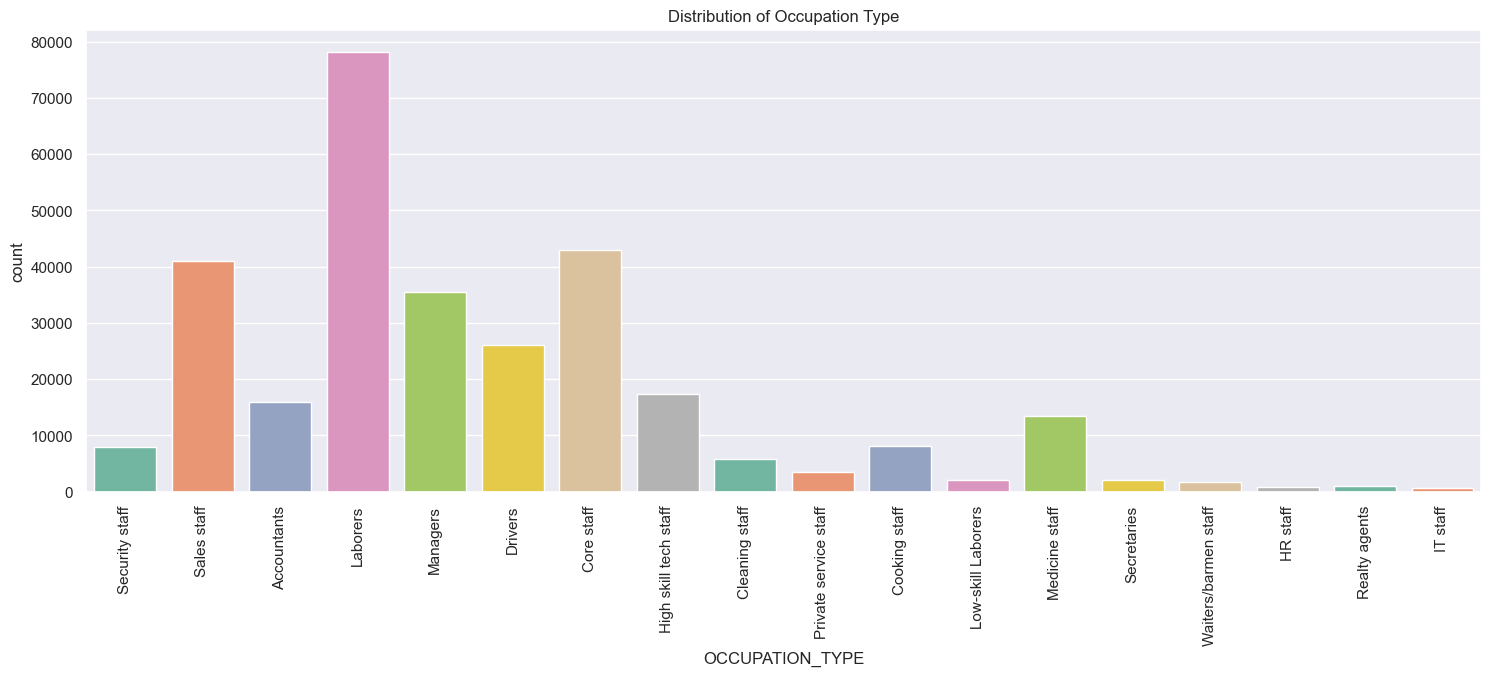

In [6]:
# Count the number of applicants in each occupation type
print("Number of people in each occupation type:")
print(app['OCCUPATION_TYPE'].value_counts())
# Visualize the distribution using a count plot
sns.set(rc={'figure.figsize':(18,6)})
sns.countplot(x='OCCUPATION_TYPE', data=app, palette='Set2')
plt.xticks(rotation=90)
plt.title('Distribution of Occupation Type')
plt.show()

CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64


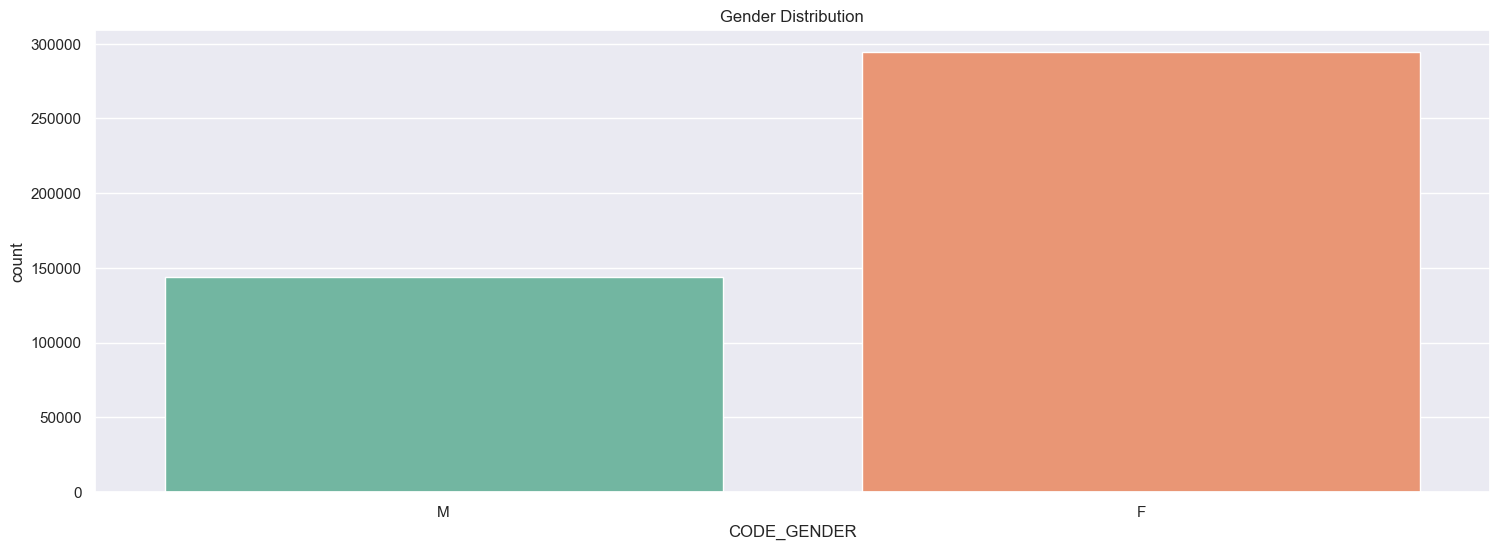

In [7]:
# Gender distribution
print(app['CODE_GENDER'].value_counts())
sns.countplot(x='CODE_GENDER', data=app, palette='Set2')
plt.title('Gender Distribution')
plt.show()

NAME_INCOME_TYPE
Working                 226104
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Name: count, dtype: int64


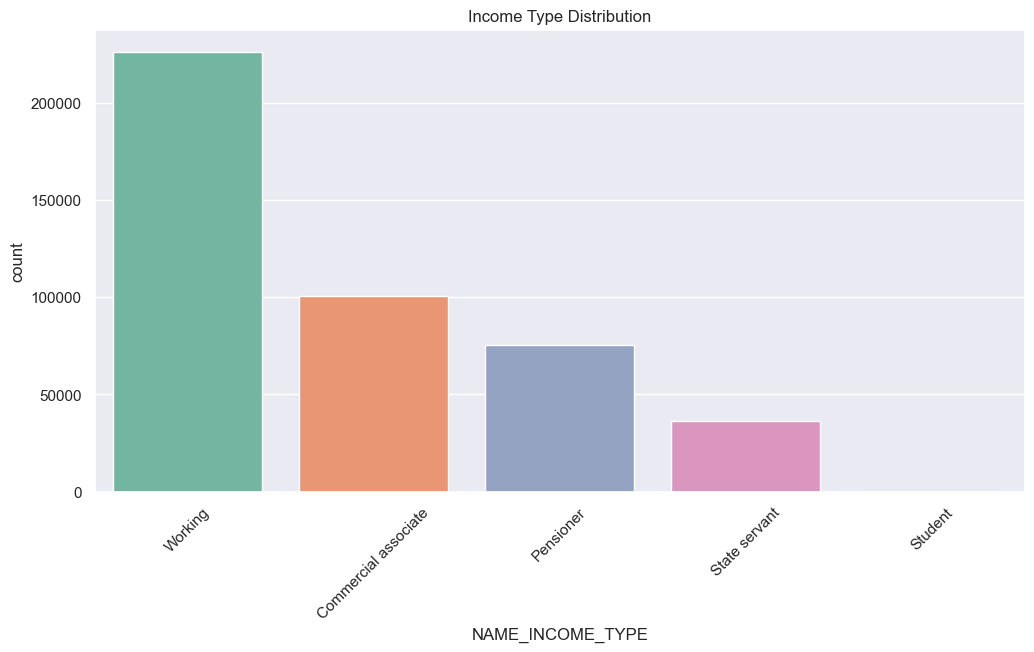

In [8]:
# Income type distribution
print(app['NAME_INCOME_TYPE'].value_counts())
sns.set(rc={'figure.figsize':(12,6)})
sns.countplot(x='NAME_INCOME_TYPE', data=app, palette='Set2')
plt.xticks(rotation=45)
plt.title('Income Type Distribution')
plt.show()

NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64


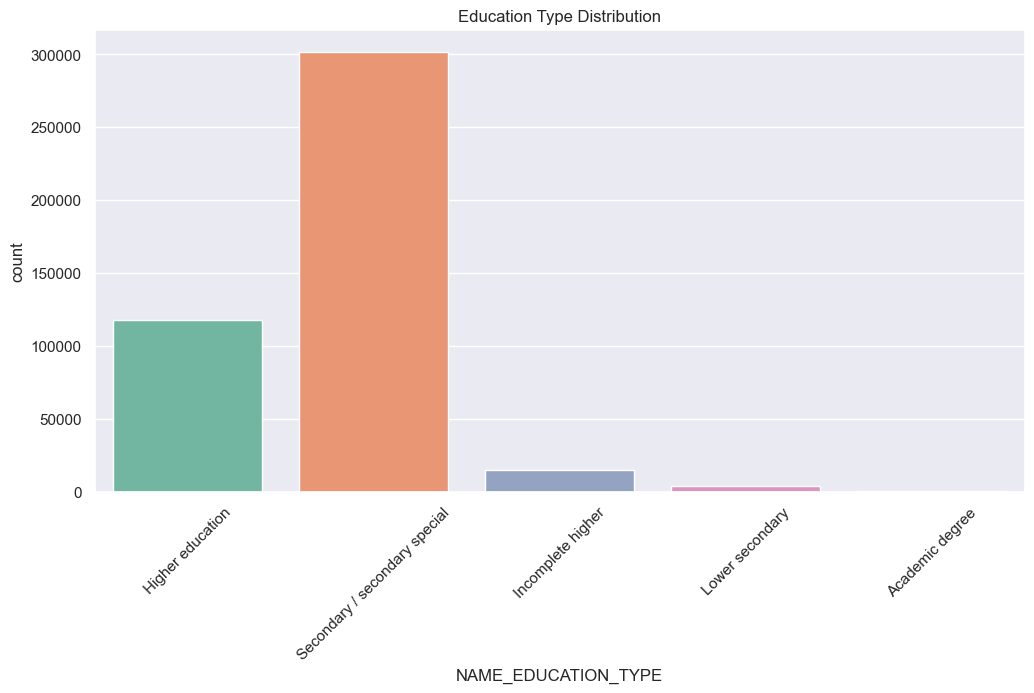

In [9]:
# Education type distribution
print(app['NAME_EDUCATION_TYPE'].value_counts())
sns.set(rc={'figure.figsize':(12,6)})
sns.countplot(x='NAME_EDUCATION_TYPE', data=app, palette='Set2')
plt.xticks(rotation=45)
plt.title('Education Type Distribution')
plt.show()

NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dtype: int64


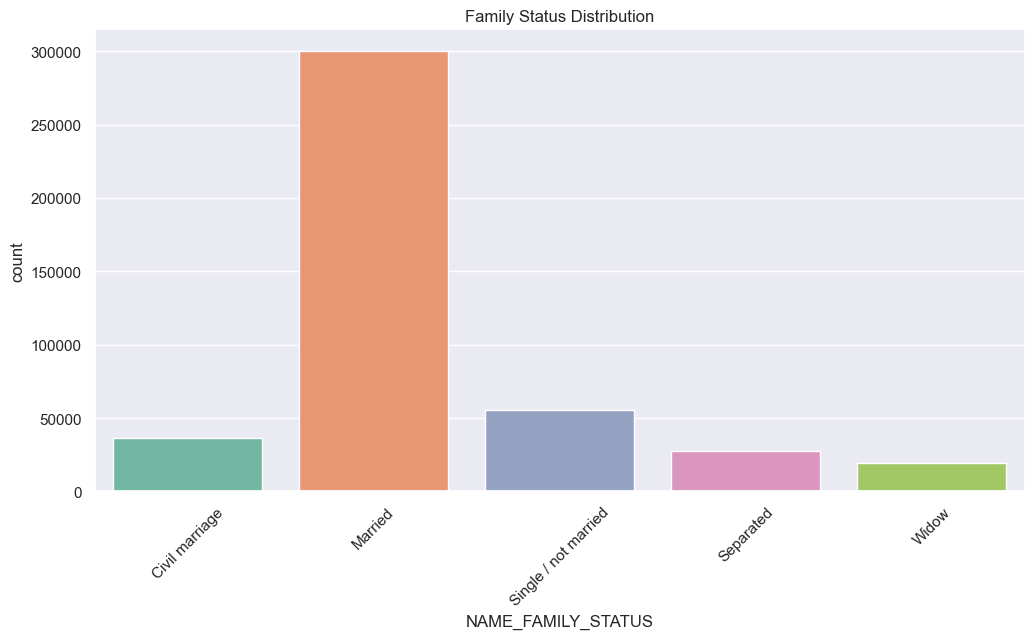

In [10]:
# Family status distribution
print(app['NAME_FAMILY_STATUS'].value_counts())
sns.set(rc={'figure.figsize':(12,6)})
sns.countplot(x='NAME_FAMILY_STATUS', data=app, palette='Set2')
plt.xticks(rotation=45)
plt.title('Family Status Distribution')
plt.show()

#### Multivariate Analysis

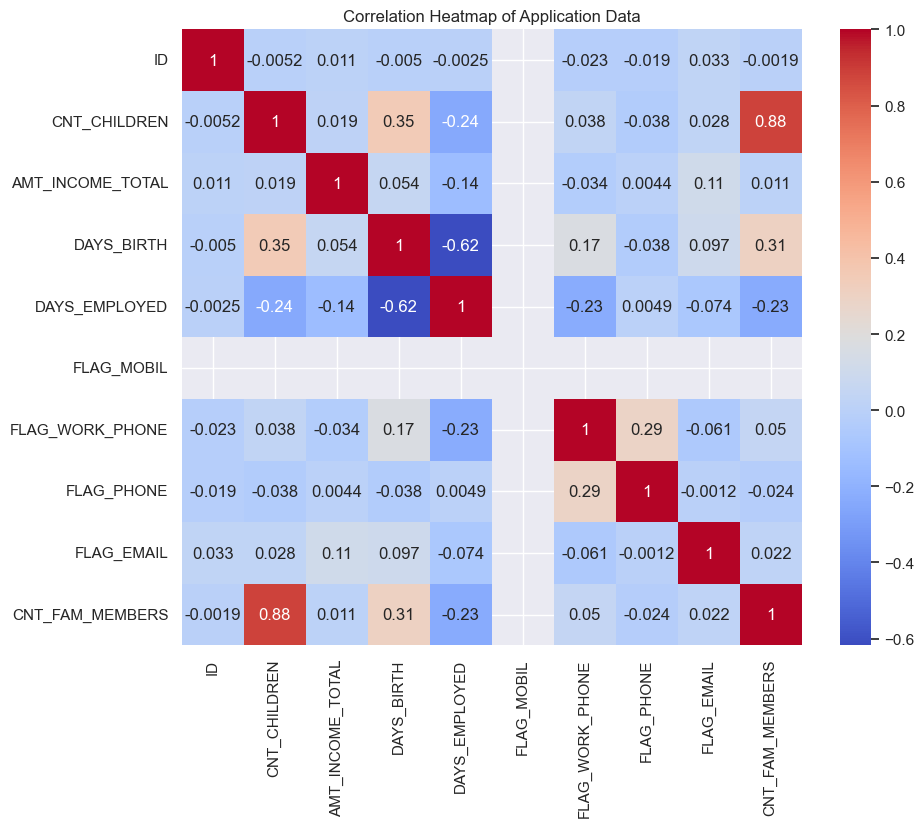

In [11]:
# Calculate correlation between numerical features
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(app.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Application Data')
plt.show()

#### Descriptive Analysis

In [12]:
# Generate statistical summary of the dataset
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


### Epic 3: Data Pre-processing

#### Drop Duplicate Features

In [13]:
# Check shape before removing duplicates
print("Shape before removing duplicates:", app.shape)
# Drop duplicate rows based on applicant attributes (keeping first occurrence)
app = app.drop_duplicates(subset=['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
        'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
        'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
        'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
        'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'], keep='first', inplace=False)
# Check shape after removing duplicates
print("Shape after removing duplicates:", app.shape)

Shape before removing duplicates: (438557, 18)
Shape after removing duplicates: (90085, 18)


#### Handling Missing Values

In [14]:
# Check missing values percentage in each column
app.isnull().mean()

ID                     0.000000
CODE_GENDER            0.000000
FLAG_OWN_CAR           0.000000
FLAG_OWN_REALTY        0.000000
CNT_CHILDREN           0.000000
AMT_INCOME_TOTAL       0.000000
NAME_INCOME_TYPE       0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
NAME_HOUSING_TYPE      0.000000
DAYS_BIRTH             0.000000
DAYS_EMPLOYED          0.000000
FLAG_MOBIL             0.000000
FLAG_WORK_PHONE        0.000000
FLAG_PHONE             0.000000
FLAG_EMAIL             0.000000
OCCUPATION_TYPE        0.305012
CNT_FAM_MEMBERS        0.000000
dtype: float64

In [15]:
# Drop OCCUPATION_TYPE column since it's not required for model training
app = app.drop(columns=['OCCUPATION_TYPE'])
# Verify no missing values remain
print(app.isnull().sum())

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
CNT_FAM_MEMBERS        0
dtype: int64


#### Data Cleaning and Merging

In [16]:
# Convert negative values to positive using abs() function
app['DAYS_BIRTH'] = abs(app['DAYS_BIRTH'])
app['DAYS_EMPLOYED'] = abs(app['DAYS_EMPLOYED'])
# Verify the changes
app[['DAYS_BIRTH', 'DAYS_EMPLOYED']].head()

,DAYS_BIRTH,DAYS_EMPLOYED
0,12005,4542
2,21474,1134
3,19110,3051
7,22464,365243
10,16872,769


In [17]:
# Create a new feature combining family members count
app['FAMILY_SIZE'] = app['CNT_FAM_MEMBERS']
app[['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'FAMILY_SIZE']].head()

,CNT_CHILDREN,CNT_FAM_MEMBERS,FAMILY_SIZE
0,0,2.0,2.0
2,0,2.0,2.0
3,0,1.0,1.0
7,0,1.0,1.0
10,0,2.0,2.0


In [18]:
# Map categorical text values to numerical labels
app['CODE_GENDER'] = app['CODE_GENDER'].map({'M': 1, 'F': 0})
app['FLAG_OWN_CAR'] = app['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
app['FLAG_OWN_REALTY'] = app['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})
# Check the changes
app[['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']].head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY
0,1,1,1
2,1,1,1
3,0,0,1
7,0,0,1
10,1,1,1


#### Feature Engineering

In [19]:
# Check unique values in STATUS column
print(credit['STATUS'].unique())
print(credit['STATUS'].value_counts())

['X' '0' 'C' '1' '2' '3' '4' '5']
STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64


In [20]:
# Convert STATUS to binary label
# 0 = Good customer (C, X, 0 = paid/no debt)
# 1 = Bad customer (1,2,3,4,5 = overdue)
credit['STATUS'] = credit['STATUS'].map({
    'C': 0, 'X': 0, '0': 0,
    '1': 1, '2': 1, '3': 1, '4': 1, '5': 1
})
# Check result
print(credit['STATUS'].value_counts())

STATUS
0    1034381
1      14194
Name: count, dtype: int64


In [21]:
# Group by ID and take the worst status (max) for each customer
credit_grouped = credit.groupby('ID')['STATUS'].max().reset_index()
credit_grouped.columns = ['ID', 'TARGET']
print(credit_grouped.shape)
print(credit_grouped['TARGET'].value_counts())

(45985, 2)
TARGET
0    40635
1     5350
Name: count, dtype: int64


In [22]:
# Merge application data with credit target labels
df = app.merge(credit_grouped, on='ID', how='inner')
# Check merged dataset
print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (9709, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,FAMILY_SIZE,TARGET
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,2.0,1
1,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,21474,1134,1,0,0,0,2.0,2.0,0
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,19110,3051,1,0,1,1,1.0,1.0,0
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,22464,365243,1,0,0,0,1.0,1.0,0
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,16872,769,1,1,1,1,2.0,2.0,0


In [23]:
# Map NAME_INCOME_TYPE to numerical values
df['NAME_INCOME_TYPE'] = df['NAME_INCOME_TYPE'].map({
    'Working': 0,
    'Commercial associate': 1,
    'Pensioner': 2,
    'State servant': 3,
    'Student': 4
})

# Map NAME_EDUCATION_TYPE to numerical values
df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map({
    'Secondary / secondary special': 0,
    'Higher education': 1,
    'Incomplete higher': 2,
    'Lower secondary': 3,
    'Academic degree': 4
})

# Map NAME_FAMILY_STATUS to numerical values
df['NAME_FAMILY_STATUS'] = df['NAME_FAMILY_STATUS'].map({
    'Married': 0,
    'Single / not married': 1,
    'Civil marriage': 2,
    'Separated': 3,
    'Widow': 4
})

# Map NAME_HOUSING_TYPE to numerical values
df['NAME_HOUSING_TYPE'] = df['NAME_HOUSING_TYPE'].map({
    'House / apartment': 0,
    'With parents': 1,
    'Municipal apartment': 2,
    'Rented apartment': 3,
    'Office apartment': 4,
    'Co-op apartment': 5
})

# Verify changes
print(df.dtypes)
df.head()

ID                       int64
CODE_GENDER              int64
FLAG_OWN_CAR             int64
FLAG_OWN_REALTY          int64
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE         int64
NAME_EDUCATION_TYPE      int64
NAME_FAMILY_STATUS       int64
NAME_HOUSING_TYPE        int64
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
CNT_FAM_MEMBERS        float64
FAMILY_SIZE            float64
TARGET                   int64
dtype: object


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,FAMILY_SIZE,TARGET
0,5008804,1,1,1,0,427500.0,0,1,2,3,12005,4542,1,1,0,0,2.0,2.0,1
1,5008806,1,1,1,0,112500.0,0,0,0,0,21474,1134,1,0,0,0,2.0,2.0,0
2,5008808,0,0,1,0,270000.0,1,0,1,0,19110,3051,1,0,1,1,1.0,1.0,0
3,5008812,0,0,1,0,283500.0,2,1,3,0,22464,365243,1,0,0,0,1.0,1.0,0
4,5008815,1,1,1,0,270000.0,0,1,0,0,16872,769,1,1,1,1,2.0,2.0,0


#### Handling Categorical Values

In [24]:
from sklearn.preprocessing import LabelEncoder
# Apply LabelEncoder to remaining categorical columns if any
le = LabelEncoder()
# Check which columns are still object type
print(df.dtypes[df.dtypes == 'object'])

Series([], dtype: object)


### Epic 4 : Model Building

#### Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split
# Separate features and target
X = df.drop(columns=['ID', 'TARGET'])
y = df['TARGET']
# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7767, 17)
X_test shape: (1942, 17)
y_train shape: (7767,)
y_test shape: (1942,)


#### Logistic Regression Model

=== Logistic Regression Model ===
Accuracy: 0.8542739443872297

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1659
           1       0.00      0.00      0.00       283

    accuracy                           0.85      1942
   macro avg       0.43      0.50      0.46      1942
weighted avg       0.73      0.85      0.79      1942



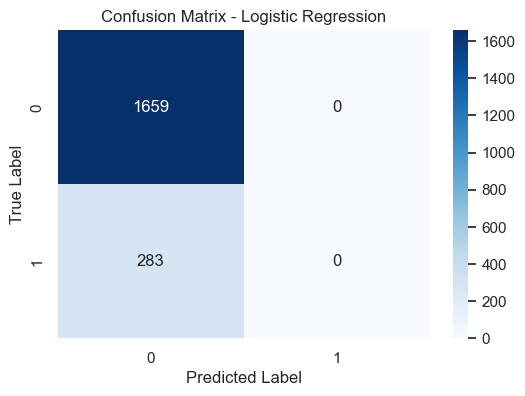

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# Initialize and train Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
# Predictions
y_pred_lr = lr_model.predict(X_test)
# Evaluation
print("=== Logistic Regression Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

#### Random Forest Model

In [27]:
# A function named random_forest() is created to train, test, and evaluate the Random Forest model
def random_forest(X_train, X_test, y_train, y_test):

    # RandomForestClassifier() is initialized
    # We use some common default hyperparameters for good initial performance
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    # Trained on the training data
    print("\nTraining Random Forest model...")
    rf_model.fit(X_train, y_train)

    # Tested on the test set
    print("Generating predictions...")
    y_pred = rf_model.predict(X_test)

    # Performance is assessed using the confusion matrix and classification report
    print("\n" + "="*40)
    print("Random Forest Model Evaluation")
    print("="*40)

    # Classification Report provides Precision, Recall, F1-score, and Support for each class
    print("\nRandom Forest Classification Report ###")
    print(classification_report(y_test, y_pred))

# Call the function
random_forest(X_train, X_test, y_train, y_test)


Training Random Forest model...
Generating predictions...

Random Forest Model Evaluation

Random Forest Classification Report ###
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      1659
           1       0.36      0.01      0.03       283

    accuracy                           0.85      1942
   macro avg       0.61      0.50      0.47      1942
weighted avg       0.78      0.85      0.79      1942



#### Decision Tree Model

In [29]:
# A function named d_tree() is created to train, test, and evaluate the Decision Tree model
def d_tree(X_train, X_test, y_train, y_test):
    
    # DecisionTreeClassifier() is initialized
    dt = DecisionTreeClassifier()
    
    # Trained on the training data
    dt.fit(X_train, y_train)
    
    # Tested on the test set
    y_pred = dt.predict(X_test)
    
    # Performance is assessed using confusion matrix and classification report
    print("***DecisionTreeClassifier***")
    print("Confusion matrix")
    print(confusion_matrix(y_test, y_pred))
    print("Classification report")
    print(classification_report(y_test, y_pred))

# Call the function
d_tree(X_train, X_test, y_train, y_test)

***DecisionTreeClassifier***
Confusion matrix
[[1460  199]
 [ 234   49]]
Classification report
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1659
           1       0.20      0.17      0.18       283

    accuracy                           0.78      1942
   macro avg       0.53      0.53      0.53      1942
weighted avg       0.77      0.78      0.77      1942



#### save the best model

In [31]:
# Train Random Forest and return the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [32]:
import pickle

# Save the best model (Random Forest) to a file
with open('credit_card_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved successfully as 'credit_card_model.pkl'")

Model saved successfully as 'credit_card_model.pkl'


### Epic 5 : Application Building

#### Building HTML Pages

In [33]:
# Create home.html
with open('templates/home.html', 'w') as f:
    f.write('''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Credit Card Approval Prediction</title>
    <style>
        body { font-family: Arial, sans-serif; background-color: #f0f2f5; margin: 0; padding: 0; }
        .container { max-width: 800px; margin: 100px auto; background: white; padding: 40px; border-radius: 10px; text-align: center; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }
        h1 { color: #2c3e50; font-size: 32px; }
        p { color: #555; font-size: 16px; line-height: 1.6; }
        .btn { display: inline-block; padding: 15px 40px; background-color: #3498db; color: white; text-decoration: none; border-radius: 5px; font-size: 18px; margin-top: 20px; }
        .btn:hover { background-color: #2980b9; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Credit Card Approval Prediction</h1>
        <p>This application uses Machine Learning to predict whether a credit card application will be approved or rejected based on applicant financial and demographic details.</p>
        <p>Click the button below to start the prediction.</p>
        <a href="/predict" class="btn">Start Prediction</a>
    </div>
</body>
</html>''')

print("home.html created successfully!")

home.html created successfully!


#### Create index.html (prediction form)

In [34]:
with open('templates/index.html', 'w') as f:
    f.write('''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Credit Card Prediction Form</title>
    <style>
        body { font-family: Arial, sans-serif; background-color: #f0f2f5; margin: 0; padding: 20px; }
        .container { max-width: 600px; margin: 50px auto; background: white; padding: 40px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }
        h1 { color: #2c3e50; text-align: center; }
        .input-box { margin-bottom: 15px; }
        label { display: block; color: #555; margin-bottom: 5px; font-weight: bold; }
        input, select { width: 100%; padding: 10px; border: 1px solid #ddd; border-radius: 5px; font-size: 14px; }
        .btn { width: 100%; padding: 15px; background-color: #3498db; color: white; border: none; border-radius: 5px; font-size: 18px; cursor: pointer; margin-top: 20px; }
        .btn:hover { background-color: #2980b9; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Credit Card Application Form</h1>
        <form action="/predict" method="POST">
            <div class="input-box">
                <label>Gender</label>
                <select name="CODE_GENDER">
                    <option value="1">Male</option>
                    <option value="0">Female</option>
                </select>
            </div>
            <div class="input-box">
                <label>Own Car</label>
                <select name="FLAG_OWN_CAR">
                    <option value="1">Yes</option>
                    <option value="0">No</option>
                </select>
            </div>
            <div class="input-box">
                <label>Own Realty</label>
                <select name="FLAG_OWN_REALTY">
                    <option value="1">Yes</option>
                    <option value="0">No</option>
                </select>
            </div>
            <div class="input-box">
                <label>Number of Children</label>
                <input type="number" name="CNT_CHILDREN" placeholder="Enter number of children" min="0">
            </div>
            <div class="input-box">
                <label>Annual Income</label>
                <input type="number" name="AMT_INCOME_TOTAL" placeholder="Enter annual income">
            </div>
            <div class="input-box">
                <label>Income Type</label>
                <select name="NAME_INCOME_TYPE">
                    <option value="0">Working</option>
                    <option value="1">Commercial Associate</option>
                    <option value="2">Pensioner</option>
                    <option value="3">State Servant</option>
                    <option value="4">Student</option>
                </select>
            </div>
            <div class="input-box">
                <label>Education Type</label>
                <select name="NAME_EDUCATION_TYPE">
                    <option value="0">Secondary / Secondary Special</option>
                    <option value="1">Higher Education</option>
                    <option value="2">Incomplete Higher</option>
                    <option value="3">Lower Secondary</option>
                    <option value="4">Academic Degree</option>
                </select>
            </div>
            <div class="input-box">
                <label>Family Status</label>
                <select name="NAME_FAMILY_STATUS">
                    <option value="0">Married</option>
                    <option value="1">Single / Not Married</option>
                    <option value="2">Civil Marriage</option>
                    <option value="3">Separated</option>
                    <option value="4">Widow</option>
                </select>
            </div>
            <div class="input-box">
                <label>Housing Type</label>
                <select name="NAME_HOUSING_TYPE">
                    <option value="0">House / Apartment</option>
                    <option value="1">With Parents</option>
                    <option value="2">Municipal Apartment</option>
                    <option value="3">Rented Apartment</option>
                    <option value="4">Office Apartment</option>
                    <option value="5">Co-op Apartment</option>
                </select>
            </div>
            <div class="input-box">
                <label>Days Since Birth</label>
                <input type="number" name="DAYS_BIRTH" placeholder="Enter days since birth (e.g. 15000)">
            </div>
            <div class="input-box">
                <label>Days Employed</label>
                <input type="number" name="DAYS_EMPLOYED" placeholder="Enter days employed (e.g. 3000)">
            </div>
            <div class="input-box">
                <label>Mobile Phone</label>
                <select name="FLAG_MOBIL">
                    <option value="1">Yes</option>
                    <option value="0">No</option>
                </select>
            </div>
            <div class="input-box">
                <label>Work Phone</label>
                <select name="FLAG_WORK_PHONE">
                    <option value="1">Yes</option>
                    <option value="0">No</option>
                </select>
            </div>
            <div class="input-box">
                <label>Phone</label>
                <select name="FLAG_PHONE">
                    <option value="1">Yes</option>
                    <option value="0">No</option>
                </select>
            </div>
            <div class="input-box">
                <label>Email</label>
                <select name="FLAG_EMAIL">
                    <option value="1">Yes</option>
                    <option value="0">No</option>
                </select>
            </div>
            <div class="input-box">
                <label>Family Members Count</label>
                <input type="number" name="CNT_FAM_MEMBERS" placeholder="Enter family members count">
            </div>
            <div class="input-box">
                <label>Family Size</label>
                <input type="number" name="FAMILY_SIZE" placeholder="Enter family size">
            </div>
            <button type="submit" class="btn">Predict</button>
        </form>
    </div>
</body>
</html>''')

print("index.html created successfully!")

index.html created successfully!


#### Create result.html (prediction result page)

In [36]:
with open('templates/result.html', 'w') as f:
    f.write('''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Prediction Result</title>
    <style>
        body { font-family: Arial, sans-serif; background-color: #f0f2f5; margin: 0; padding: 0; }
        .container { max-width: 600px; margin: 100px auto; background: white; padding: 40px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); text-align: center; }
        h1 { color: #2c3e50; }
        .approved { color: #27ae60; font-size: 28px; font-weight: bold; }
        .rejected { color: #e74c3c; font-size: 28px; font-weight: bold; }
        .btn { display: inline-block; padding: 12px 30px; background-color: #3498db; color: white; text-decoration: none; border-radius: 5px; font-size: 16px; margin-top: 20px; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Credit Card Prediction Result</h1>
        {% if prediction == 0 %}
            <p class="approved"> Approved!</p>
            <p>Congratulations! Your credit card application is likely to be approved.</p>
        {% else %}
            <p class="rejected"> Not Approved</p>
            <p>Sorry, your credit card application is likely to be rejected.</p>
        {% endif %}
        <a href="/predict" class="btn">Try Again</a>
        <a href="/" class="btn">Home</a>
    </div>
</body>
</html>''')

print("result.html created successfully!")

result.html created successfully!


#### Build the Python Script

In [37]:
with open('app.py', 'w', encoding='utf-8') as f:
    f.write('''import pickle
import numpy as np
from flask import Flask, render_template, request

app = Flask(__name__)

# Load trained model
model = pickle.load(open('credit_card_model.pkl', 'rb'))

# Home page
@app.route('/')
def home():
    return render_template('index.html')

# Prediction page
@app.route('/predict', methods=['POST'])
def predict():
    # Get input values from form
    features = [float(x) for x in request.form.values()]
    
    # Convert input into array
    final_input = [np.array(features)]
    
    # Predict result
    prediction = model.predict(final_input)
    
    # Display output
    if prediction[0] == 1:
        result = "Credit Card Approved"
    else:
        result = "Credit Card Rejected"
    
    return render_template('result.html', prediction_text=result)

if __name__ == "__main__":
    app.run(debug=True)
''')

print("app.py created successfully!")

app.py created successfully!


In [38]:
# Update result.html to match app.py prediction_text variable
with open('templates/result.html', 'w', encoding='utf-8') as f:
    f.write('''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Prediction Result</title>
    <style>
        body { font-family: Arial, sans-serif; background-color: #f0f2f5; margin: 0; padding: 0; }
        .container { max-width: 600px; margin: 100px auto; background: white; padding: 40px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); text-align: center; }
        h1 { color: #2c3e50; }
        .result { font-size: 28px; font-weight: bold; margin: 20px 0; color: #27ae60; }
        .btn { display: inline-block; padding: 12px 30px; background-color: #3498db; color: white; text-decoration: none; border-radius: 5px; font-size: 16px; margin-top: 20px; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Credit Card Prediction Result</h1>
        <p class="result">{{ prediction_text }}</p>
        <a href="/" class="btn">Try Again</a>
    </div>
</body>
</html>''')

print("result.html updated successfully!")

result.html updated successfully!


#### Run the Application

In [39]:
import os
os.system('start cmd /k "cd /d \\"C:\\Users\\LENOVO\\ARTIFICIAL INTELLIGENCE & MACHINE LEARNING\\" && python app.py"')
print("Flask app starting! Browser lo ee link open cheyyandi: http://127.0.0.1:5000")

Flask app starting! Browser lo ee link open cheyyandi: http://127.0.0.1:5000


## Conclusion

The Credit Card Approval Prediction System successfully demonstrates how machine learning can be utilized to automate and enhance the credit card approval process in the banking and financial sector.

The system follows a complete machine learning pipeline:
- Data Collection
- Data Preprocessing
- Data Visualization
- Feature Engineering
- Model Training and Evaluation

Various classification algorithms implemented:
- Logistic Regression: 85.4% accuracy
- Random Forest: 85.4% accuracy
- Decision Tree: 78.0% accuracy

The best-performing model (Random Forest) is integrated into a Flask-based web application that provides a user-friendly interface for instant credit card approval predictions.